In [31]:
import casadi as cs
import numpy as np
import pickle
from matplotlib import pyplot as plt
from NMM.solver import Continuation_Solver
from MPC.solver_2steps import Solver
from time import time

In [32]:
data_locomotion = pickle.load(open('data/locomotion4.pkl', 'rb'))
data_switch = pickle.load(open('data/switch4.pkl','rb'))

In [33]:
def reorder(branch):
    traj = np.array(branch)
    idx = 0
    for i in range(traj.shape[0] -1):
        if np.linalg.norm(traj[i+1,:] - traj[i,:]) > 0.02:
            idx = i+1
    fixed_traj = np.vstack([np.flip(traj[:idx,:],axis=0),traj[idx:,:]])
    if traj[-1,3] < -1e-2 or traj[0,3] < -1e-2:
        fixed_traj[:,[0,2,3,5]] = - fixed_traj[:,[0,2,3,5]]
    return fixed_traj

def separate(traj):
    idx = 0
    for i in range(100,traj.shape[0] -101):
        de1 = traj[i,-1] - traj[i-1,-1]
        de2 = traj[i+1,-1] - traj[i,-1]
        if de1*de2 < 0:
            idx = i + 1
    return traj[:idx,:],traj[idx:,:]

def flip(traj):
    flipped_traj = np.zeros(traj.shape)
    for i in range(traj.shape[0]):
        flipped_traj[i] = traj[traj.shape[0]-1-i]
    return flipped_traj

L1 = reorder(data_locomotion[2])
S1 = np.flip(reorder(data_switch[2]),axis = 0)
L1,_ = separate(L1)
L1_ = L1.copy()
L1_[:,[0,2,3,5]] = - L1[:,[0,2,3,5]]
S1_ = S1.copy()
S1_[:,[0,2,3,5]] = - S1[:,[0,2,3,5]]

In [34]:

def getLUT(NMM):
    N_SAMPLES = 100
    skip = max(1,int(NMM.shape[0]/N_SAMPLES))
    NMM_sampled = NMM[10:-10:skip,:]
    E_grid = NMM_sampled[:,-1]
    values = NMM_sampled.ravel(order="C")
    LUT = cs.interpolant('LUT', 'bspline',[E_grid],values)
    return LUT,E_grid[0],E_grid[-1]

LUT_L1,Emin_L1,Emax_L1 = getLUT(L1)
LUT_L1_,Emin_L1_,Emax_L1_ = getLUT(L1_)
LUT_S1,Emin_S1,Emax_S1 = getLUT(S1)
LUT_S1_,Emin_S1_,Emax_S1_ = getLUT(S1_)

solver_RL = Solver(50,40,1,Emin_S1_,Emax_S1_,LUT_S1_,True)
solver_L = Solver(50,40,1,Emin_L1_,Emax_L1_,LUT_L1_,False)

In [35]:
def get_trajectory(solver,u):
    x0,dt,xi = u[:6],u[6:9],u[9]
    traj1 = solver.traj_f_list(x0, dt[0], xi)
    traj2 = solver.stance_to_flight(
        solver.traj_s_list(solver.flight_to_stance(traj1[:, -1]), dt[1], xi)
    )
    traj3 = solver.traj_f_list(traj2[:, -1], dt[2], xi)
    traj4 = solver.traj_f_list(traj3[:,-1], dt[0], xi)
    traj = cs.horzcat(traj2, traj2[:,-1], traj3[:,:-1], traj4)
    return np.array(traj)

E_star = 2.8
u_fw = LUT_L1(E_star)
u_bw = LUT_L1_(E_star)
u_fw_to_bw = LUT_S1(E_star)
u_bw_to_fw = LUT_S1_(E_star)
fw = get_trajectory(solver_L,u_fw)
bw = get_trajectory(solver_L,u_bw)
fw_to_bw = get_trajectory(solver_L,u_fw_to_bw)
bw_to_fw = get_trajectory(solver_L,u_bw_to_fw)



In [36]:
## first step with solver_RL

x0 = fw[[0,1,3,4],0]
xs_init = [fw[[0,1,3,4],:solver_RL.N],fw_to_bw[[0,1,3,4],:solver_RL.N]]
xf_init = [fw[:,solver_RL.N:],fw_to_bw[:,solver_RL.N:]]
dt_init = cs.vertcat(u_fw[6]+u_fw[8],u_fw[7],u_fw[6]+u_fw[8],u_fw[7])
solver_RL.initialize(x0,xs_init,xf_init,dt_init)
start = time()
sol = solver_RL.solve()
end = time()
print(end-start)

0.5510239601135254


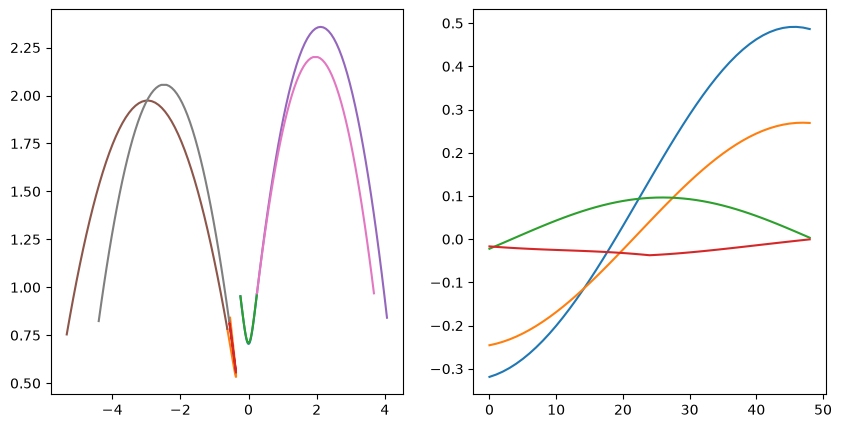

In [37]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,2)
for us in sol["stance_control"]:
    plt.plot(us)
for uf in sol["flight_control"]:
    plt.plot(uf)
# plt.plot(fw[0,:],fw[1,:])
# plt.plot(xs_init[0][0,:].T,xs_init[0][1,:].T)
# plt.plot(xf_init[0][0,:].T,xf_init[0][1,:].T)
plt.subplot(1,2,1)
for xs in sol["stance"]:
    plt.plot(xs[0,:],xs[1,:])
for xs in xs_init:
    plt.plot(xs[0,:],xs[1,:])

for xf in sol["flight"]:
    plt.plot(xf[0,:],xf[1,:])
for xf in xf_init:
    plt.plot(xf[0,:],xf[1,:])
# plt.plot(bw[0,:],bw[1,:])
# plt.plot(fw_to_bw[0,:],fw_to_bw[1,:])
# plt.plot(bw_to_fw[0,:],bw_to_fw[1,:])
plt.show()

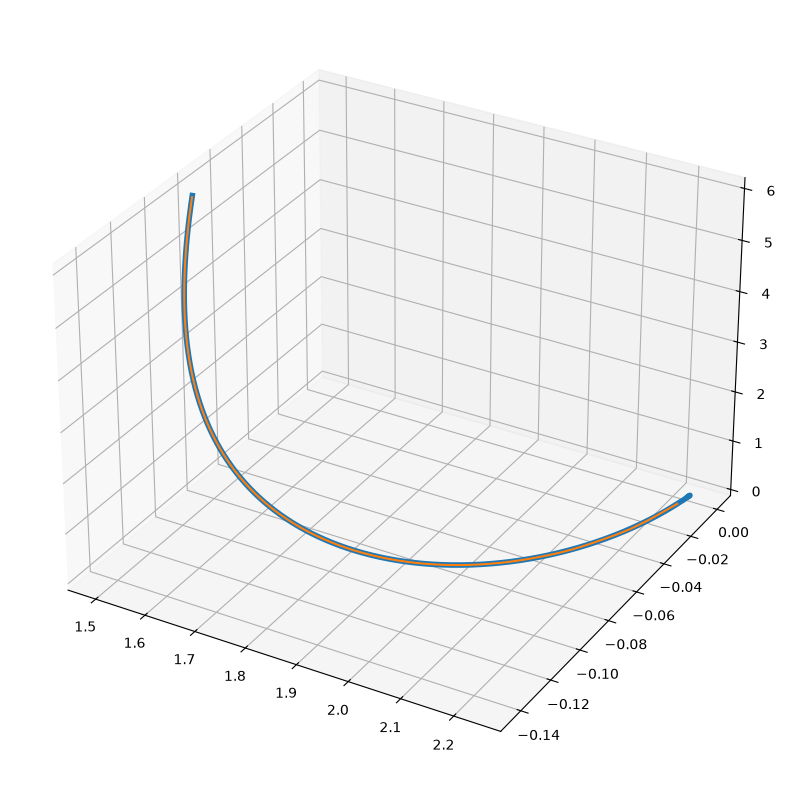

In [38]:
E_grid = np.linspace(Emin_S1,Emax_S1,1000).reshape((-1,))
S1_i = np.zeros((1000,11))
for i in range(1000):
    S1_i[i,:] = np.array(LUT_S1(E_grid[i])).reshape((-1,))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1,projection='3d')
ax.plot(S1[:,1],S1[:,2],S1[:,3],linewidth=4)
ax.plot(S1_i[:,1],S1_i[:,2],S1_i[:,3])
